<a href="https://colab.research.google.com/github/Abhishek3102/ML/blob/main/Face_Mask_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
!pip install kaggle

In [50]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [51]:
!kaggle datasets download -d ashishjangra27/face-mask-12k-images-dataset

Dataset URL: https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset
License(s): CC0-1.0
face-mask-12k-images-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [52]:
from zipfile import ZipFile
dataset = "/content/face-mask-12k-images-dataset.zip"

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("Successfully extracted!!!")

Successfully extracted!!!


In [53]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [54]:
with_mask_files = os.listdir("/content/Face Mask Dataset/Train/WithMask")
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['Augmented_316_7588018.png', '1287.png', 'Augmented_36_5212114.png', 'Augmented_243_8628654.png', 'Augmented_855_1387465.png']
['Augmented_828_5381005.png', 'Augmented_38_4979159.png', 'Augmented_447_6057545.png', 'Augmented_55_2366996.png', 'Augmented_600_8566628.png']


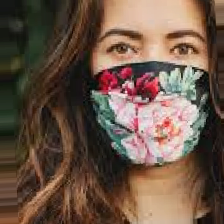

In [55]:
with_mask_image = cv2.imread("/content/Face Mask Dataset/Train/WithMask/Augmented_385_198218.png")
cv2_imshow(with_mask_image)

In [56]:
without_mask_files = os.listdir("/content/Face Mask Dataset/Train/WithoutMask")
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['1031.png', '4681.png', '3673.png', '4748.png', '2211.png']
['3297.png', '3421.png', '3752.png', '4650.png', '4579.png']


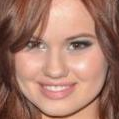

In [57]:
without_mask_image = cv2.imread("/content/Face Mask Dataset/Train/WithoutMask/4751.png")
cv2_imshow(without_mask_image)

In [58]:
print("Number of images with mask are :",len(with_mask_files))
print("Number of images without mask are :",len(without_mask_files))

Number of images with mask are : 5000
Number of images without mask are : 5000


In [59]:
with_mask_labels = [1] * len(with_mask_files)

without_mask_labels = [0] * len(without_mask_files)

In [60]:
print(with_mask_labels[0:5])
print(with_mask_labels[-5:])

print(without_mask_labels[0:5])
print(without_mask_labels[-5:])

[1, 1, 1, 1, 1]
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]
[0, 0, 0, 0, 0]


In [61]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

10000
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


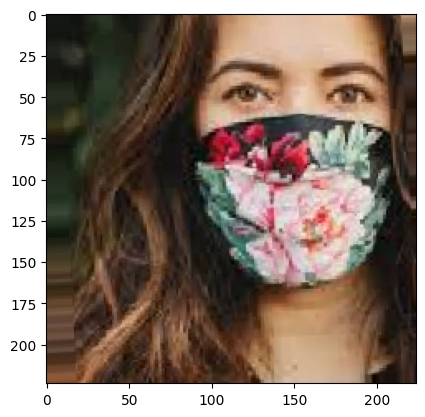

In [62]:
mask_img = mpimg.imread("/content/Face Mask Dataset/Train/WithMask/Augmented_385_198218.png")
plt.imshow(mask_img)

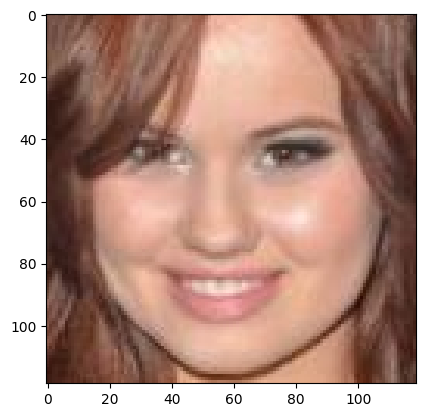

In [63]:
without_mask_img = mpimg.imread("/content/Face Mask Dataset/Train/WithoutMask/4751.png")
plt.imshow(without_mask_img)

In [64]:
# Converting the images to numpy arrays
with_mask_path = "/content/Face Mask Dataset/Train/WithMask/"

data = []
for img_file in with_mask_files:
  image = Image.open(with_mask_path + img_file)
  image = image.resize((224,224))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

In [65]:
without_mask_path = "/content/Face Mask Dataset/Train/WithoutMask/"

for img_file in without_mask_files:
  image = Image.open(without_mask_path + img_file)
  image = image.resize((224,224))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

In [66]:
print(len(data))

10000


In [67]:
type(data)

list

array([[[130,  98,  99],
        [135, 100, 102],
        [135, 100, 102],
        ...,
        [ 45,  32,  25],
        [ 45,  32,  25],
        [ 45,  32,  25]],

       [[130,  98,  99],
        [134, 100, 100],
        [135, 100, 102],
        ...,
        [ 47,  34,  28],
        [ 50,  37,  29],
        [ 51,  38,  32]],

       [[130,  98,  99],
        [132, 100, 100],
        [135, 100, 102],
        ...,
        [ 54,  41,  33],
        [ 54,  41,  33],
        [ 54,  41,  33]],

       ...,

       [[ 34,   2,   7],
        [ 34,   2,   7],
        [ 34,   2,   7],
        ...,
        [ 22,  18,  27],
        [ 23,  18,  25],
        [ 23,  18,  25]],

       [[ 34,   2,   7],
        [ 34,   2,   7],
        [ 34,   2,   7],
        ...,
        [ 22,  18,  27],
        [ 23,  18,  25],
        [ 23,  18,  25]],

       [[ 34,   2,   7],
        [ 34,   2,   7],
        [ 34,   2,   7],
        ...,
        [ 22,  18,  27],
        [ 23,  18,  25],
        [ 23,  18,  25]]], dtype=uint8)
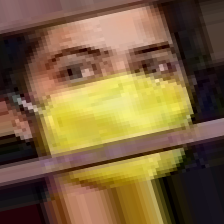

In [68]:
data[0]

In [69]:
print(data[0].shape)

(224, 224, 3)


array([[[21, 21, 21],
        [21, 21, 21],
        [21, 21, 21],
        ...,
        [ 9,  9,  9],
        [ 9,  9,  9],
        [ 9,  9,  9]],

       [[21, 21, 21],
        [19, 19, 19],
        [19, 19, 19],
        ...,
        [ 9,  9,  9],
        [ 9,  9,  9],
        [ 9,  9,  9]],

       [[19, 19, 19],
        [19, 19, 19],
        [19, 19, 19],
        ...,
        [ 9,  9,  9],
        [ 9,  9,  9],
        [ 9,  9,  9]],

       ...,

       [[44, 43, 57],
        [44, 43, 57],
        [44, 43, 57],
        ...,
        [18, 18, 18],
        [18, 18, 18],
        [18, 18, 18]],

       [[44, 43, 57],
        [44, 43, 57],
        [44, 43, 57],
        ...,
        [18, 18, 18],
        [18, 18, 18],
        [18, 18, 18]],

       [[44, 43, 57],
        [44, 43, 57],
        [44, 43, 57],
        ...,
        [18, 18, 18],
        [18, 18, 18],
        [18, 18, 18]]], dtype=uint8)
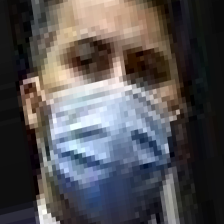

In [70]:
data[320]

In [71]:
# Converting the image list and label list to a numpy array
X = np.array(data)
Y = np.array(labels)

In [72]:
type(X)
type(Y)

numpy.ndarray

In [73]:
print(X.shape)
print(Y.shape)

(10000, 224, 224, 3)
(10000,)


In [74]:
print(Y)

[1 1 1 ... 0 0 0]


In [75]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [76]:
print(X.shape, X_train.shape, X_test.shape)

(10000, 224, 224, 3) (8000, 224, 224, 3) (2000, 224, 224, 3)


In [77]:
# Scaling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [78]:
X_train_scaled[0]

array([[[0.19215686, 0.19607843, 0.14117647],
        [0.18431373, 0.18823529, 0.13333333],
        [0.16470588, 0.17647059, 0.12156863],
        ...,
        [0.55294118, 0.39215686, 0.32156863],
        [0.54509804, 0.38431373, 0.31764706],
        [0.54509804, 0.38039216, 0.31764706]],

       [[0.19607843, 0.19607843, 0.14509804],
        [0.2       , 0.2       , 0.14509804],
        [0.19215686, 0.19607843, 0.14117647],
        ...,
        [0.54901961, 0.39215686, 0.31764706],
        [0.54117647, 0.38431373, 0.31372549],
        [0.54117647, 0.38039216, 0.31372549]],

       [[0.21176471, 0.20392157, 0.15686275],
        [0.22352941, 0.21568627, 0.16470588],
        [0.24313725, 0.23529412, 0.17647059],
        ...,
        [0.53333333, 0.38431373, 0.30980392],
        [0.52941176, 0.37647059, 0.30588235],
        [0.52941176, 0.37647059, 0.30588235]],

       ...,

       [[0.97254902, 1.        , 0.71764706],
        [0.97254902, 1.        , 0.71372549],
        [0.96862745, 1

**Building a Convulational Neural Network**

In [89]:
import tensorflow as tf
from tensorflow import keras

In [90]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(224,224,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes, activation='softmax'))

In [92]:
# naya chatgpt waala/
data_gen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [94]:
# Compiling the Neural Network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [83]:
# # Training the Neural Network
# history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
225/225 [==============================] - 88s 393ms/step - loss: 0.0950 - acc: 0.9689 - val_loss: 0.0810 - val_acc: 0.9775
Epoch 2/10
225/225 [==============================] - 88s 389ms/step - loss: 0.0587 - acc: 0.9794 - val_loss: 0.0627 - val_acc: 0.9800
Epoch 3/10
225/225 [==============================] - 87s 388ms/step - loss: 0.0498 - acc: 0.9833 - val_loss: 0.0449 - val_acc: 0.9875
Epoch 4/10
225/225 [==============================] - 88s 390ms/step - loss: 0.0397 - acc: 0.9860 - val_loss: 0.0424 - val_acc: 0.9862
Epoch 5/10
225/225 [==============================] - 89s 394ms/step - loss: 0.0310 - acc: 0.9911 - val_loss: 0.0782 - val_acc: 0.9850
Epoch 6/10
225/225 [==============================] - 87s 388ms/step - loss: 0.0417 - acc: 0.9854 - val_loss: 0.0750 - val_acc: 0.9762
Epoch 7/10
225/225 [==============================] - 88s 389ms/step - loss: 0.0277 - acc: 0.9914 - val_loss: 0.0639 - val_acc: 0.9825
Epoch 8/10
225/225 [==============================] - 8

In [97]:
# Assuming you have X_val_scaled and Y_val as your validation data
history = model.fit(
    data_gen.flow(X_train_scaled, Y_train, batch_size=32),
    validation_data=(X_test_scaled, Y_test),  # Use validation_data instead of validation_split
    epochs=10
)

Epoch 1/10
250/250 [==============================] - 109s 432ms/step - loss: 0.5217 - acc: 0.8435 - val_loss: 0.2027 - val_acc: 0.9220
Epoch 2/10
250/250 [==============================] - 106s 424ms/step - loss: 0.2409 - acc: 0.9181 - val_loss: 0.1613 - val_acc: 0.9415
Epoch 3/10
250/250 [==============================] - 106s 423ms/step - loss: 0.2158 - acc: 0.9219 - val_loss: 0.1208 - val_acc: 0.9560
Epoch 4/10
250/250 [==============================] - 106s 422ms/step - loss: 0.1956 - acc: 0.9316 - val_loss: 0.0939 - val_acc: 0.9685
Epoch 5/10
250/250 [==============================] - 106s 421ms/step - loss: 0.1915 - acc: 0.9384 - val_loss: 0.0950 - val_acc: 0.9690
Epoch 6/10
250/250 [==============================] - 105s 421ms/step - loss: 0.1695 - acc: 0.9425 - val_loss: 0.1205 - val_acc: 0.9535
Epoch 7/10
250/250 [==============================] - 107s 426ms/step - loss: 0.1604 - acc: 0.9413 - val_loss: 0.0911 - val_acc: 0.9705
Epoch 8/10
250/250 [============================

In [98]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming X_test and y_test are your test data and labels
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(confusion_matrix(Y_test, y_pred_classes))
print(classification_report(Y_test, y_pred_classes))


63/63 [==============================] - 5s 71ms/step
[[544 456]
 [ 12 988]]
              precision    recall  f1-score   support

           0       0.98      0.54      0.70      1000
           1       0.68      0.99      0.81      1000

    accuracy                           0.77      2000
   macro avg       0.83      0.77      0.75      2000
weighted avg       0.83      0.77      0.75      2000



Model Evaluation

In [99]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print("Test Accuracy", accuracy)

63/63 [==============================] - 4s 67ms/step - loss: 0.1068 - acc: 0.9705
Test Accuracy 0.9704999923706055


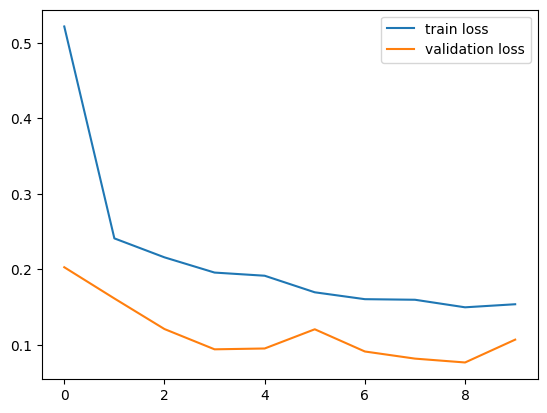

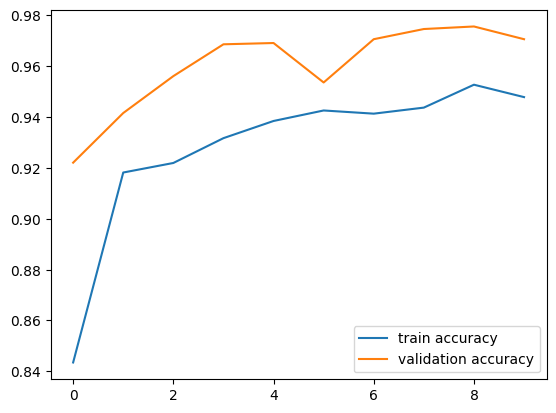

In [100]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuarcy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Building a predictive system**

Enter the path of the image to be predicted :/content/ANU MASK PHOTO.jpg


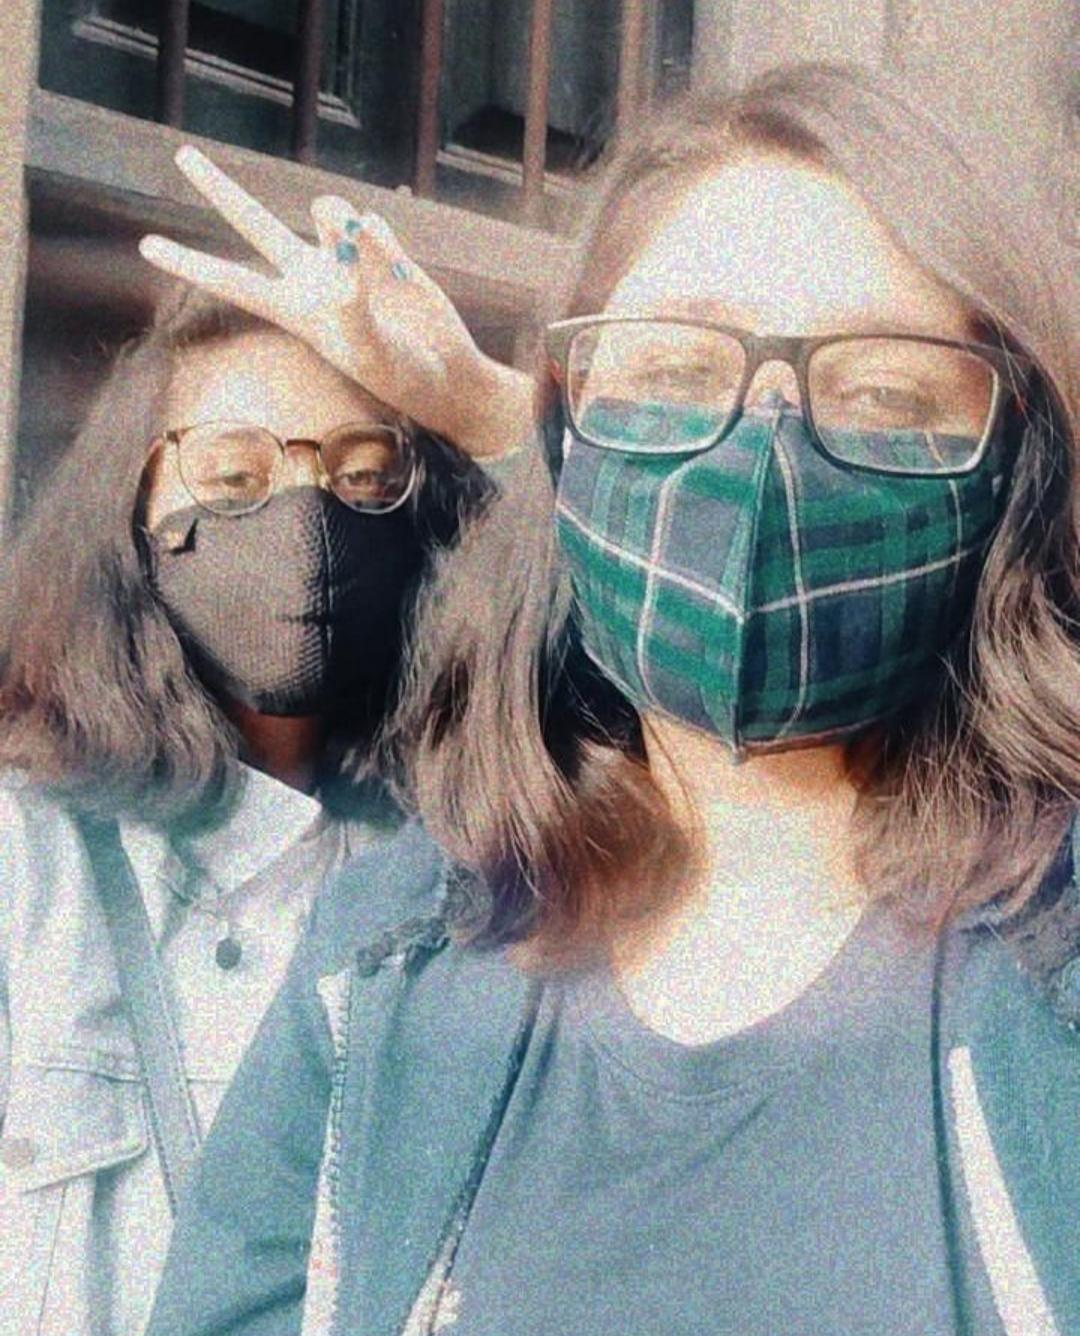

1/1 [==============================] - 0s 94ms/step
[[6.7498325e-04 9.9932504e-01]]
1
The person in the image is wearing a mask


In [87]:
input_image_path = input("Enter the path of the image to be predicted :")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

input_image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
  print("The person in the image is wearing a mask")
else:
  print("The person in the image is not wearing a mask")

In [ ]:
input_image_path = input("Enter the path of the image to be predicted :")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

input_image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
  print("The person in the image is wearing a mask")
else:
  print("The person in the image is not wearing a mask")

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras

image_path = "/content/MINDY_KALING.jpeg"

# Preprocess image
def preprocess_image(image_path):
    input_image = cv2.imread(image_path)
    input_image_resize = cv2.resize(input_image, (224, 224))
    input_image_scaled = input_image_resize / 255.0
    input_image_reshaped = np.reshape(input_image_scaled, [1, 224, 224, 3])
    return input_image_reshaped

# Predict mask
def predict_mask(image_path, model):
    processed_image = preprocess_image(image_path)
    prediction = model.predict(processed_image)
    predicted_label = np.argmax(prediction, axis=1)[0]
    return predicted_label

# Test predictions on individual images
test_image_paths = ["path_to_no_mask_image.jpg", "path_to_mask_image.jpg"]
for img_path in test_image_paths:
    label = predict_mask(img_path, model)
    print(f"Image: {img_path}, Predicted Label: {'Wearing Mask' if label == 1 else 'No Mask'}")
